# Ridge Regression — SDY524 (single institution)

**Per-study notebook in the federated architecture.**

This notebook fits a Ridge regression on **SDY524 alone** to predict
log(C-peptide AUC). It is one "institution" in the federated simulation:
it never sees any other study's subject-level data. Its only output that
leaves this notebook is a **coefficient vector** (saved as a CSV), which a
separate federated-aggregation notebook combines with the other studies'
vectors using a chosen aggregation rule.

- **Input:** SDY524's Panel A and Panel B feature matrices.
- **Output:** `vectors/SDY524_ridge_panelA_vector.csv` and `vectors/SDY524_ridge_panelB_vector.csv`.

Redundant by design: each study has its own identical-structure notebook so
the per-institution step is explicit and inspectable.


## Why Ridge, not plain OLS

For small studies the OLS coefficient vector is **unstable** and the Ridge
vector is **stable**.

Both are multivariate linear regression — both produce a coefficient vector
with one weight per feature. The difference is how the weights are picked:

- **OLS** picks the weights that minimize prediction error.
- **Ridge** picks the weights that minimize prediction error **and adds a
  penalty on large weights** (the L2 penalty). This shrinks the weights
  toward zero.

When a study has more features than subjects (e.g. SDY569: 10 subjects,
several features), OLS cannot solve for the weights stably and they blow up.
The L2 penalty keeps them bounded, so each study produces a usable, stable
vector.


## 1. Setup

In [1]:
from __future__ import annotations
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

REPO = Path.cwd()
if (REPO / "src").exists():
    sys.path.insert(0, str(REPO / "src"))
elif (REPO.parent / "src").exists():
    REPO = REPO.parent
    sys.path.insert(0, str(REPO / "src"))
os.chdir(REPO)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

import oadr_data as od

RNG_SEED = 42
RIDGE_ALPHA = 1.0      # L2 penalty strength (same for every study so vectors are comparable)
np.random.seed(RNG_SEED)
(REPO / "vectors").mkdir(exist_ok=True)
(REPO / "figures").mkdir(exist_ok=True)
print("Repo root:", REPO)


Repo root: /Users/adeslatt/Scitechcon Dropbox/Anne DeslattesMays/projects/oadr-autoantibody


## 2. Load SDY524 only

Panel A is the 9-feature legacy panel (5 autoantibodies + 3 age-group
dummies + Sex). Panel B is the 12-feature extended panel (Sex, age, disease duration, BMI, height, weight, the 5 autoantibodies, and a treatment flag). Race and ethnicity are deliberately excluded from Panel B: their categories differ across studies, so the one-hot columns would not align for federated aggregation.

The feature lists are fixed constants (not derived from the data) so that
every study emits a vector in the same feature order.


In [2]:
# --- Panel A (SDY524) : build from this study's rows only ---
PANEL_A_FEATS = ['MIAA', 'GAD65', 'IA2IC', 'ICA', 'ZNT8', '8-12', '13-17', '>18', 'Sex']
a = od.load_panel_a("SDY524")
Xa = a[PANEL_A_FEATS].values.astype(float)
ya = a[od.PANEL_A_TARGET].values.astype(float)
print(f"Panel A: N={len(ya)}, features={len(PANEL_A_FEATS)}")

# --- Panel B (SDY524) : build from this study's rows only ---
PANEL_B_FEATS = ['Sex', 'age_years', 'disease_duration_years', 'bmi', 'height_cm', 'weight_kg', 'GAD65', 'IA2IC', 'MIAA', 'ZNT8', 'ICA', 'received_active_treatment']
b_raw = od.load_panel_b("SDY524")            # single-study raw frame
# within-study clean-up (this study's own median; per-row height repair)
for col in ("bmi", "height_cm", "weight_kg"):
    b_raw[col] = b_raw[col].fillna(b_raw[col].median())
bad_h = b_raw["height_cm"] <= 0
b_raw.loc[bad_h, "height_cm"] = np.sqrt(b_raw.loc[bad_h, "weight_kg"] / b_raw.loc[bad_h, "bmi"]) * 100
Xb_full, yb, _ = od.panel_b_design_matrix(b_raw)
Xb = Xb_full.reindex(columns=PANEL_B_FEATS).values.astype(float)   # keep canonical 12, drop race/ethnicity
yb = yb.values.astype(float)
print(f"Panel B: N={len(yb)}, features={len(PANEL_B_FEATS)}")


Panel A: N=75, features=9
Panel B: N=72, features=12


## 3. MinMaxScaler — within-study harmonization

Autoantibody assays are on very different scales across studies (e.g. GAD65
ranges 0–1155 IU/ml in some studies but is recorded 0/1 in others). **Within
SDY524 only**, each feature is min–max scaled to [0, 1]. This is the
preprocessing step every institution applies to its own data before any
coefficient is shared — exactly as a real federated protocol requires (and
matching the deck). Binary indicators (Sex, age-group dummies) are already
0/1 and are unchanged.


In [3]:
sc_a = MinMaxScaler().fit(Xa)
Xa_s = sc_a.transform(Xa)
if Xb is not None:
    sc_b = MinMaxScaler().fit(Xb)
    Xb_s = sc_b.transform(Xb)
else:
    Xb_s = None
print("MinMax-scaled Panel A shape:", Xa_s.shape)


MinMax-scaled Panel A shape: (75, 9)


## 4. Fit Ridge and write the SDY524 coefficient vector

Ridge is fit on **all** of SDY524's MinMax-scaled rows (α = `RIDGE_ALPHA`).
The coefficient vector — one weight per feature, plus the intercept and the
study's sample size — is written to `vectors/`. That CSV is the only thing
this institution shares.


In [4]:
def fit_and_save(X_r, y, feats, panel_label):
    m = Ridge(alpha=RIDGE_ALPHA).fit(X_r, y)
    rows = [{"feature": "__intercept__", "coefficient": float(m.intercept_)}]
    rows += [{"feature": f, "coefficient": float(c)} for f, c in zip(feats, m.coef_)]
    vec = pd.DataFrame(rows)
    vec["n_subjects"] = len(y)
    vec["study"] = "SDY524"
    vec["panel"] = panel_label
    vec["alpha"] = RIDGE_ALPHA
    path = f"vectors/{"SDY524"}_ridge_panel{panel_label}_vector.csv"
    vec.to_csv(path, index=False)
    print(f"Wrote {path}")
    return vec


In [5]:
vec_a = fit_and_save(Xa_s, ya, PANEL_A_FEATS, "A")
print()
print("Panel A coefficient vector:")
print(vec_a[["feature", "coefficient"]].to_string(index=False))

vec_b = fit_and_save(Xb_s, yb, PANEL_B_FEATS, "B")
print()
print("Panel B coefficient vector:")
print(vec_b[["feature", "coefficient"]].to_string(index=False))


Wrote vectors/SDY524_ridge_panelA_vector.csv

Panel A coefficient vector:
      feature  coefficient
__intercept__    -0.502799
         MIAA     0.121410
        GAD65    -0.278776
        IA2IC    -0.118935
          ICA     0.000000
         ZNT8     0.173990
         8-12    -0.190893
        13-17     0.061294
          >18     0.129600
          Sex     0.142713
Wrote vectors/SDY524_ridge_panelB_vector.csv

Panel B coefficient vector:
                  feature  coefficient
            __intercept__    -1.160600
                      Sex     0.095495
                age_years     0.055583
   disease_duration_years     0.216468
                      bmi     0.326800
                height_cm     0.297426
                weight_kg     0.388519
                    GAD65    -0.202876
                    IA2IC    -0.048821
                     MIAA     0.059777
                     ZNT8     0.042521
                      ICA     0.000000
received_active_treatment     0.111973


## 5. SDY524 coefficient graphic

This study's Ridge coefficient vector as a horizontal bar chart — green for a
positive weight (higher value → higher predicted C-peptide AUC), red for
negative. Panel A (left) and Panel B (right) side by side. This is the per-study picture; the
federated notebook later shows how these per-study vectors combine.


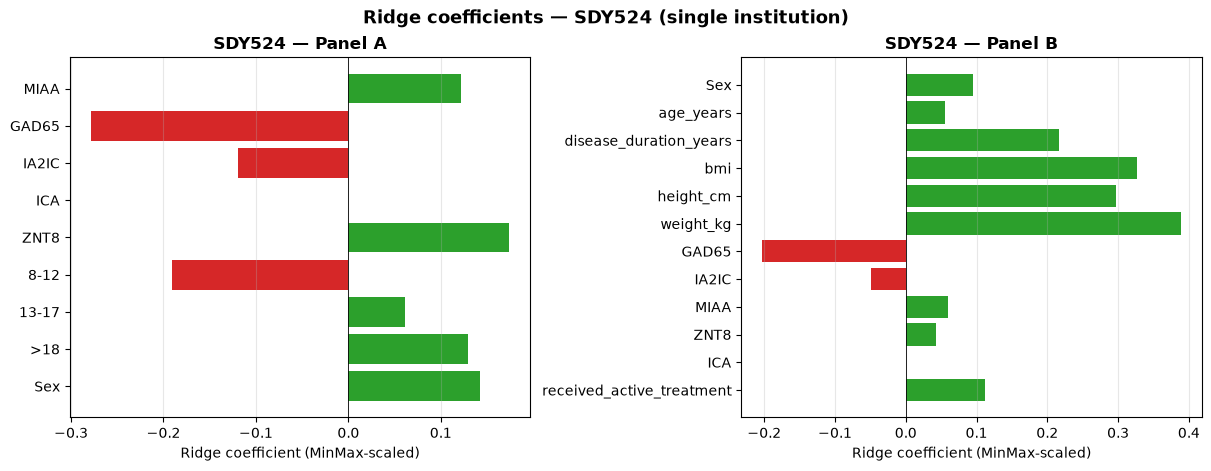

In [6]:
def plot_coef(ax, vec, title):
    d = vec[vec.feature != "__intercept__"]
    colors = ["#2ca02c" if c > 0 else "#d62728" for c in d.coefficient]
    ax.barh(d.feature, d.coefficient, color=colors)
    ax.axvline(0, color="k", lw=0.6)
    ax.invert_yaxis()
    ax.set_xlabel("Ridge coefficient (MinMax-scaled)")
    ax.set_title(title, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)

panels = ["A", "B"]
vecs = {"A": vec_a, "B": vec_b}
fig, axes = plt.subplots(1, len(panels), figsize=(6.0 * len(panels), 4.6),
                         constrained_layout=True, squeeze=False)
for ax, p in zip(axes[0], panels):
    plot_coef(ax, vecs[p], f"SDY524 — Panel {p}")
fig.suptitle("Ridge coefficients — SDY524 (single institution)",
             fontsize=13, fontweight="bold")
fig.savefig("figures/ridge_coef_SDY524.pdf", dpi=300)
fig.savefig("figures/ridge_coef_SDY524.png", dpi=220)
plt.show()


## 6. Solo performance (within-study cross-validation)

For context — what SDY524 achieves **on its own**, before federation.
5-fold cross-validation within SDY524 (fewer folds if N is small). The
MinMaxScaler is fit on each training fold and applied to the held-out fold,
so no fold uses its own scaling. This number is the baseline the federated
model will be compared against later.


In [7]:
def solo_cv(X, y, n_splits=5, seed=RNG_SEED):
    n_splits = max(2, min(n_splits, len(y) // 2))
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    preds = np.full_like(y, np.nan, dtype=float)
    for tr, te in kf.split(X):
        sc = MinMaxScaler().fit(X[tr])
        m = Ridge(alpha=RIDGE_ALPHA).fit(sc.transform(X[tr]), y[tr])
        preds[te] = m.predict(sc.transform(X[te]))
    mask = ~np.isnan(preds)
    mse = mean_squared_error(y[mask], preds[mask])
    rss = np.sum((y[mask] - preds[mask]) ** 2)
    tss = np.sum((y[mask] - y[mask].mean()) ** 2)
    r2 = 1 - rss / tss if tss > 0 else float("nan")
    return mse, r2, n_splits

mse_a, r2_a, k_a = solo_cv(Xa, ya)
print(f"Panel A solo {k_a}-fold CV:  MSE={mse_a:.3f}  R²={r2_a:+.3f}")
if Xb is not None:
    mse_b, r2_b, k_b = solo_cv(Xb, yb)
    print(f"Panel B solo {k_b}-fold CV:  MSE={mse_b:.3f}  R²={r2_b:+.3f}")


Panel A solo 5-fold CV:  MSE=0.134  R²=+0.015
Panel B solo 5-fold CV:  MSE=0.095  R²=+0.312


## 7. Outputs

Vectors written to `vectors/`:

- `SDY524_ridge_panelA_vector.csv`
- `SDY524_ridge_panelB_vector.csv`

Figure written to `figures/`:

- `ridge_coef_SDY524.pdf` / `.png`

Each CSV has one row per feature (`coefficient`), plus `__intercept__`, and
carries `n_subjects`, `study`, `panel`, and `alpha` so the federated
aggregation notebook has everything it needs (e.g. sample-size weighting)
without ever reading SDY524's subject-level data.

Next: the **federated Ridge aggregation** notebook reads every
`*_ridge_panelA_vector.csv` (and Panel B where present) and combines them
with a chosen aggregation rule.
